# Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("First 10 Rows:")
display(df.head(10))

rows, cols = df.shape
print(f"\nNumber of Rows: {rows}")
print(f"Number of Columns: {cols}")

print("\nTarget Column:")
print("Attrition")

attrition_counts = df["Attrition"].value_counts()
print("\nAttrition Counts:")
print(attrition_counts)

attrition_rate = (attrition_counts["Yes"] / len(df)) * 100
print(f"\nAttrition Rate: {attrition_rate:.2f}%")

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print(f"\nNumber of Numeric Columns: {len(numeric_cols)}")
print(f"Number of Categorical Columns: {len(categorical_cols)}")

print("\nNumeric Columns:")
print(list(numeric_cols))

print("\nCategorical Columns:")
print(list(categorical_cols))

First 10 Rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7



Number of Rows: 1470
Number of Columns: 35

Target Column:
Attrition

Attrition Counts:
No     1233
Yes     237
Name: Attrition, dtype: int64

Attrition Rate: 16.12%

Number of Numeric Columns: 26
Number of Categorical Columns: 9

Numeric Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


# Task 2 — Data Cleaning & Preprocessing

In [2]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Missing Values in Each Column:")
print(df.isnull().sum())

df = df.dropna()

columns_to_drop = [
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

df = df.drop(columns=columns_to_drop)

df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

categorical_cols = X.select_dtypes(include=["object"]).columns

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("\nShape after preprocessing:")
print(X_scaled.shape)

print("\nFirst 5 rows of processed data:")
display(X_scaled.head())

print("\nTarget variable:")
display(y.head())

Missing Values in Each Column:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCu

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241



Target variable:


0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

# Task 3 — Exploratory Data Analysis — EDA

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

<Figure size 800x500 with 0 Axes>

Attrition                       0          1
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803


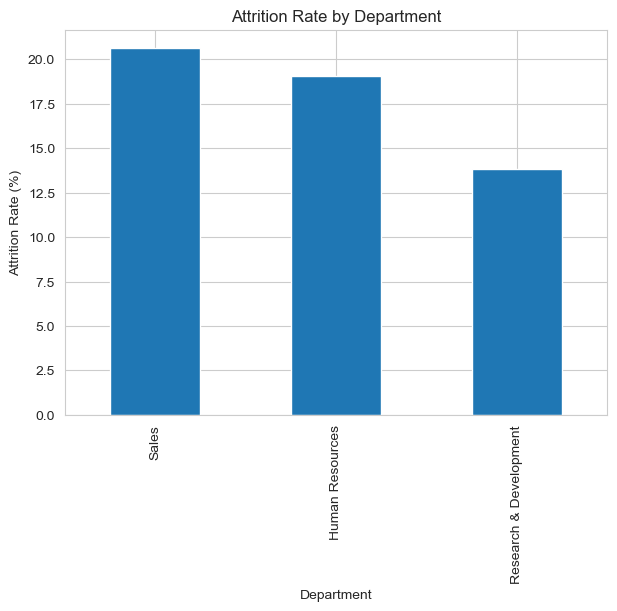

In [4]:
dept_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

print(dept_attrition)

dept_attrition[1].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")
plt.show()

Attrition                          0          1
JobRole                                        
Healthcare Representative  93.129771   6.870229
Human Resources            76.923077  23.076923
Laboratory Technician      76.061776  23.938224
Manager                    95.098039   4.901961
Manufacturing Director     93.103448   6.896552
Research Director          97.500000   2.500000
Research Scientist         83.904110  16.095890
Sales Executive            82.515337  17.484663
Sales Representative       60.240964  39.759036


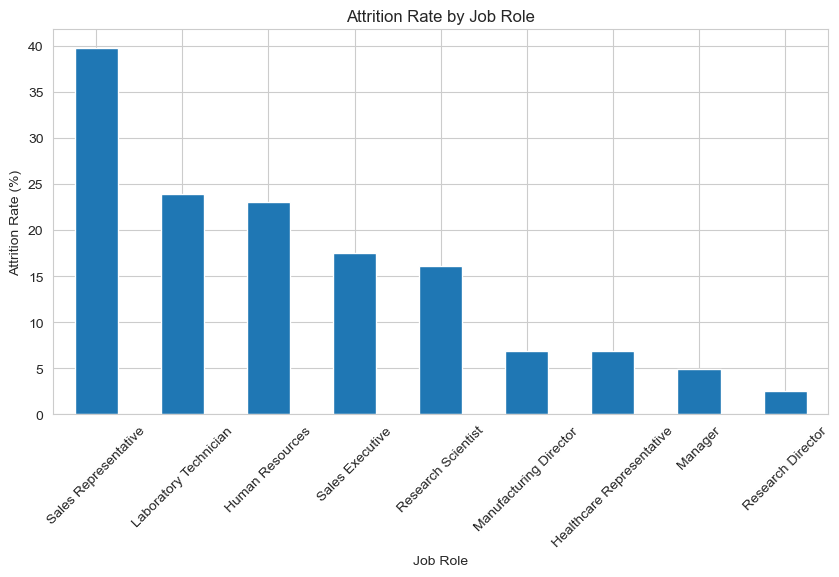

In [5]:
job_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

print(job_attrition)

job_attrition[1].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Job Role")
plt.xticks(rotation=45)
plt.show()

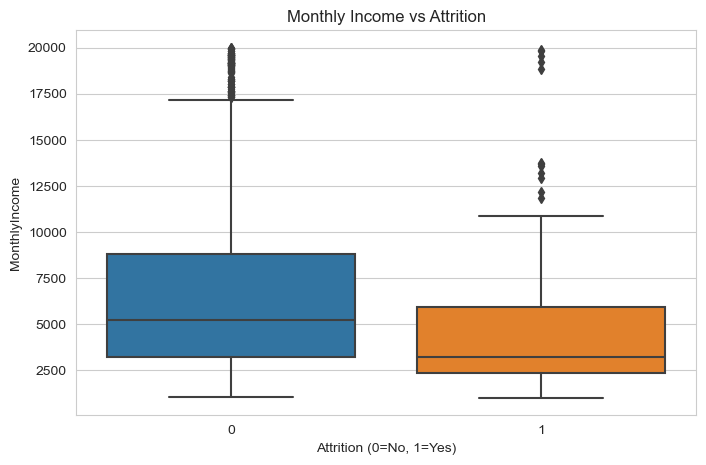

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition (0=No, 1=Yes)")
plt.show()

Attrition                0          1
WorkLifeBalance                      
1                68.750000  31.250000
2                83.139535  16.860465
3                85.778275  14.221725
4                82.352941  17.647059


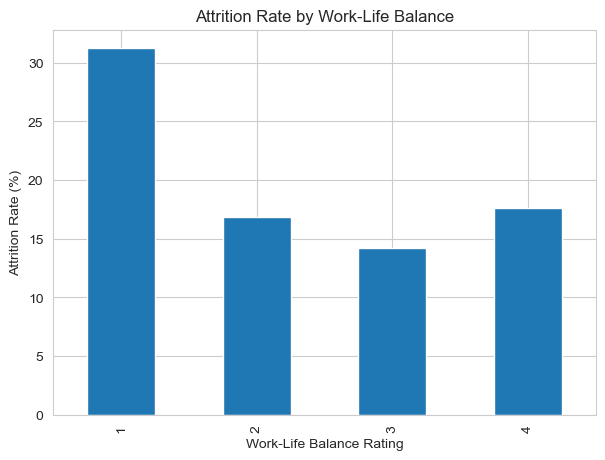

In [7]:
wlb = pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize="index"
) * 100

print(wlb)

wlb[1].plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Attrition Rate by Work-Life Balance")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Work-Life Balance Rating")
plt.show()

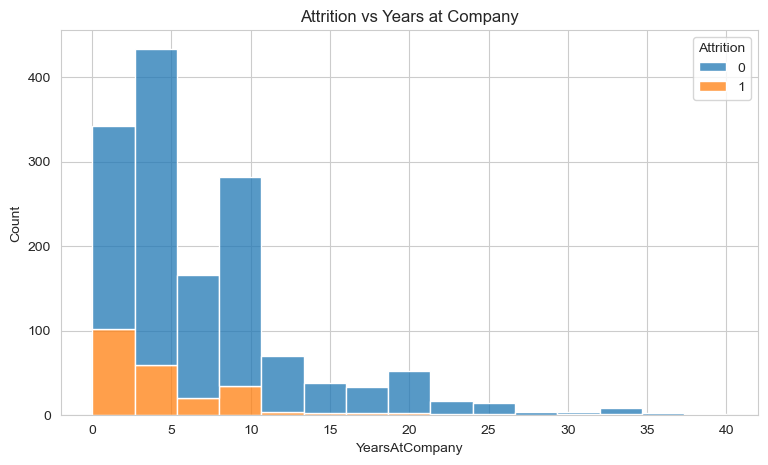

In [8]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="YearsAtCompany",
    hue="Attrition",
    bins=15,
    multiple="stack"
)

plt.title("Attrition vs Years at Company")
plt.show()

## Business Insights (IBM HR Dataset)

### 1. Sales department has the highest attrition rate, with approximately 20% of employees leaving, compared to Research & Development and Human Resources.
### 2. Sales Representatives and Laboratory Technicians experience the highest attrition, with exit rates close to 35–40%, indicating these roles require targeted retention efforts.
### 3. Employees with lower monthly incomes leave more frequently. The median salary of employees who left is noticeably lower than that of employees who stayed.
### 4. Employees with poor Work-Life Balance ratings (1 or 2) have a higher attrition rate than those rated 3 or 4, suggesting work-life balance influences employee retention.
### 5. Most employees who leave do so within the first 5 years of joining the company, indicating that early-career retention strategies could significantly reduce attrition.

# Task 4 — Model Building & Comparison

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (1176, 44)
Testing Set: (294, 44)


In [11]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [12]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

In [13]:
comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

comparison_df = comparison_df.sort_values(
    by="F1-Score",
    ascending=False
)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.748299,0.341176,0.617021,0.439394
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500
1,Random Forest,0.833333,0.375000,0.063830,0.109091


In [14]:
comparison_df.round(3)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.748,0.341,0.617,0.439
2,Gradient Boosting,0.850,0.588,0.213,0.312
1,Random Forest,0.833,0.375,0.064,0.109


# Task 5 — Model Evaluation

In [15]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import pandas as pd

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294



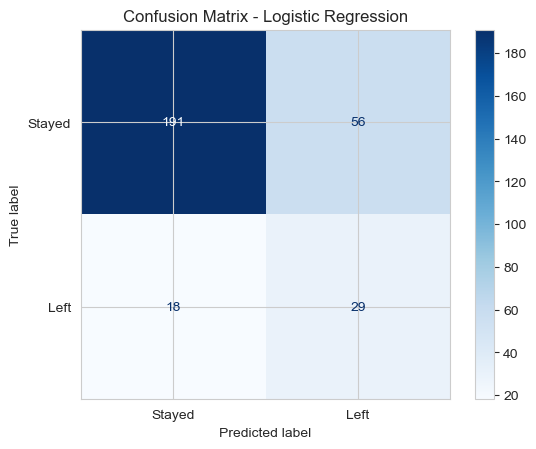

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.38      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.61      0.52      0.51       294
weighted avg       0.77      0.83      0.78       294



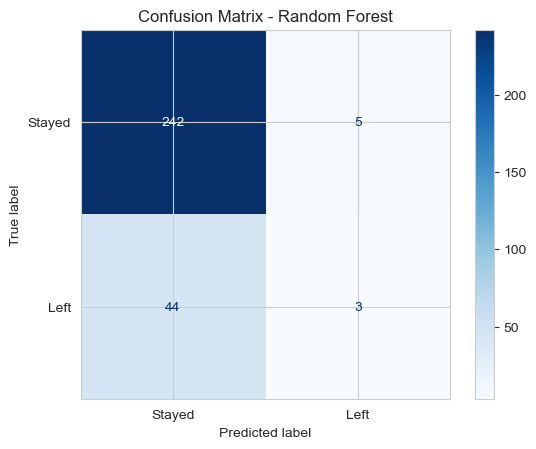

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



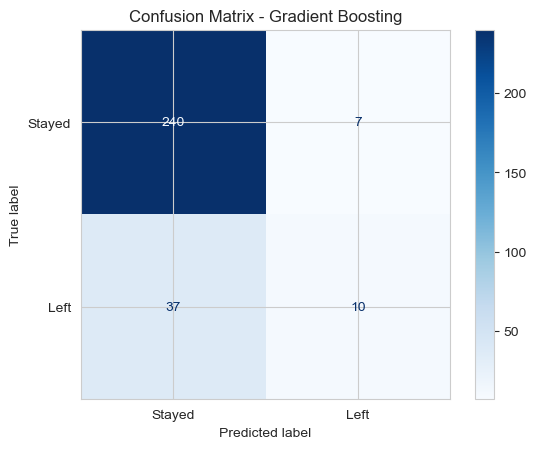

In [16]:
evaluation_results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)

    precision = report["1"]["precision"]
    recall = report["1"]["recall"]
    f1 = report["1"]["f1-score"]
    roc_auc = roc_auc_score(y_test, y_prob)

    evaluation_results.append([
        name,
        precision,
        recall,
        f1,
        roc_auc
    ])

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Stayed", "Left"]
    )

    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [17]:
evaluation_df = pd.DataFrame(
    evaluation_results,
    columns=[
        "Model",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
)

evaluation_df = evaluation_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

evaluation_df.round(3)

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.341,0.617,0.439,0.799
2,Gradient Boosting,0.588,0.213,0.312,0.794
1,Random Forest,0.375,0.064,0.109,0.752


In [18]:
best_model_name = evaluation_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [19]:
best_model = models["Logistic Regression"]

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": abs(best_model.coef_[0])
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

top10 = importance.head(10)

print(top10)

                             Feature  Importance
34     JobRole_Laboratory Technician    0.797169
43                      OverTime_Yes    0.766511
23  BusinessTravel_Travel_Frequently    0.717823
7                           JobLevel    0.664602
16                 TotalWorkingYears    0.657516
40      JobRole_Sales Representative    0.555341
24      BusinessTravel_Travel_Rarely    0.509883
27      EducationField_Life Sciences    0.502108
21           YearsSinceLastPromotion    0.499259
26                  Department_Sales    0.489760


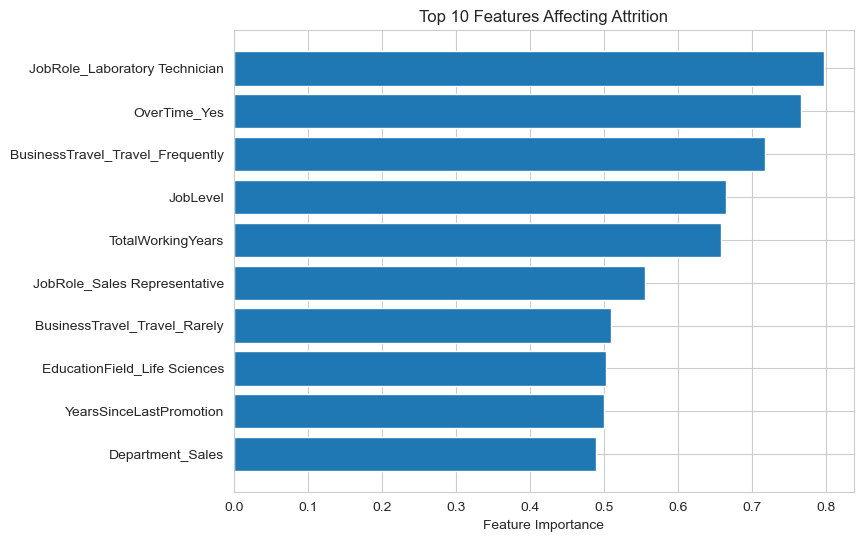

In [20]:
plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Feature Importance")
plt.title("Top 10 Features Affecting Attrition")

plt.gca().invert_yaxis()

plt.show()

# Task 6 — Visualization

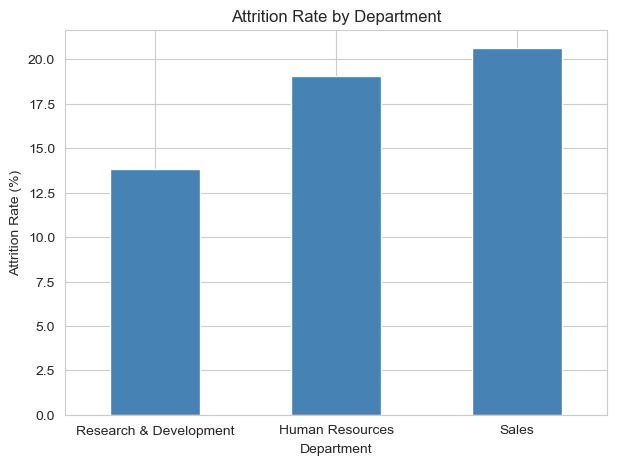

In [21]:
dept_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

plt.figure(figsize=(7,5))

dept_attrition[1].sort_values().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")
plt.xticks(rotation=0)
plt.show()

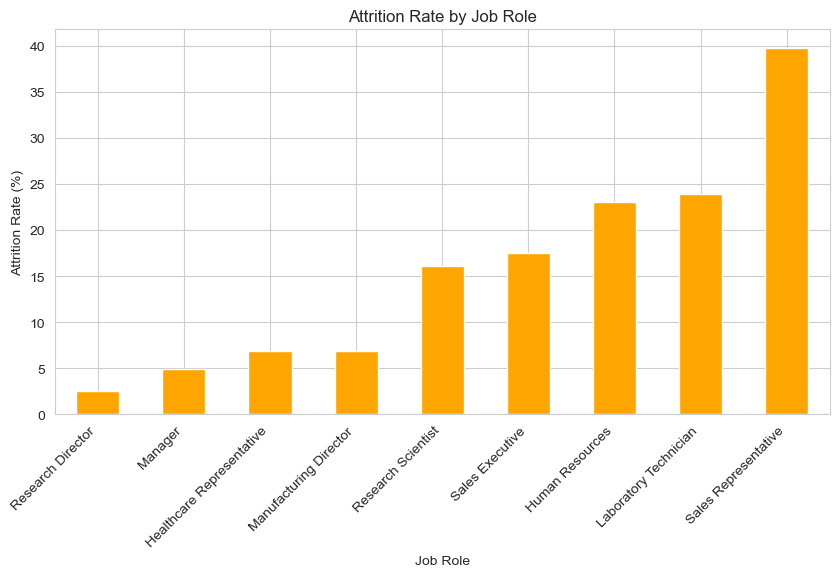

In [22]:
job_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

plt.figure(figsize=(10,5))

job_attrition[1].sort_values().plot(
    kind="bar",
    color="orange"
)

plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Job Role")
plt.xticks(rotation=45, ha="right")
plt.show()

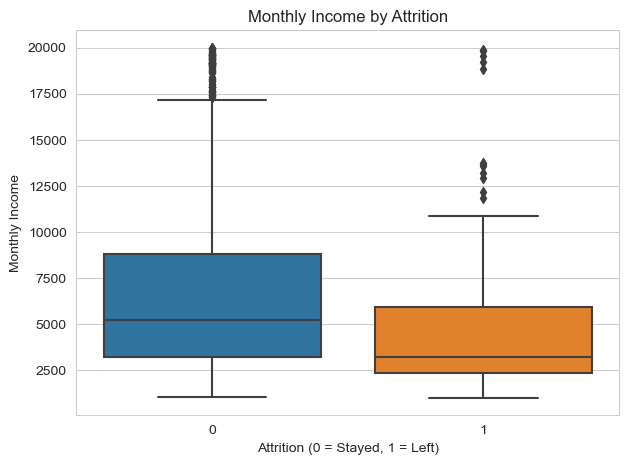

In [23]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Monthly Income")
plt.show()

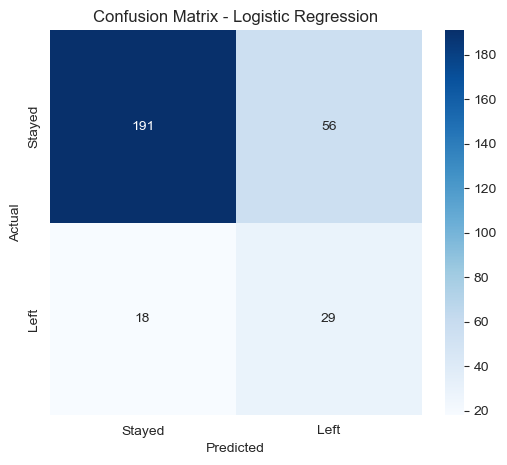

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

best_model = models["Logistic Regression"]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed","Left"],
    yticklabels=["Stayed","Left"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

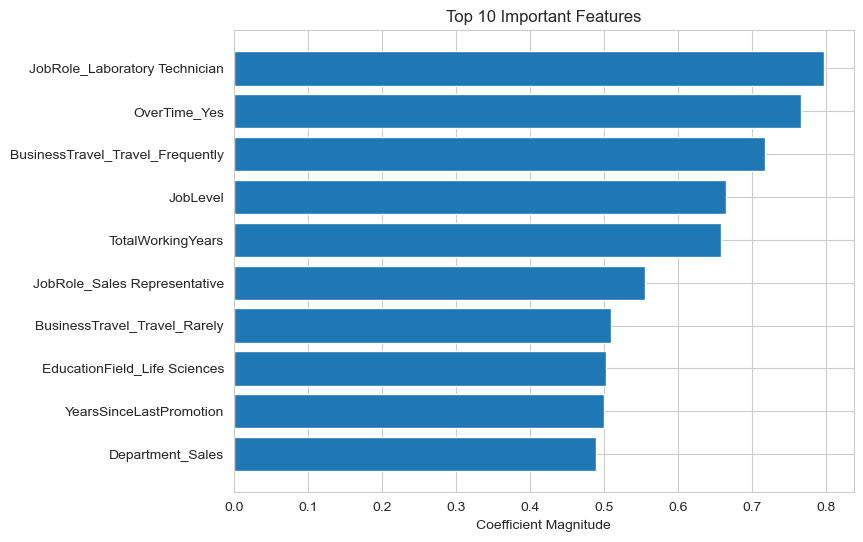

In [25]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": abs(best_model.coef_[0])
})

top10 = importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Important Features")
plt.xlabel("Coefficient Magnitude")

plt.gca().invert_yaxis()

plt.show()

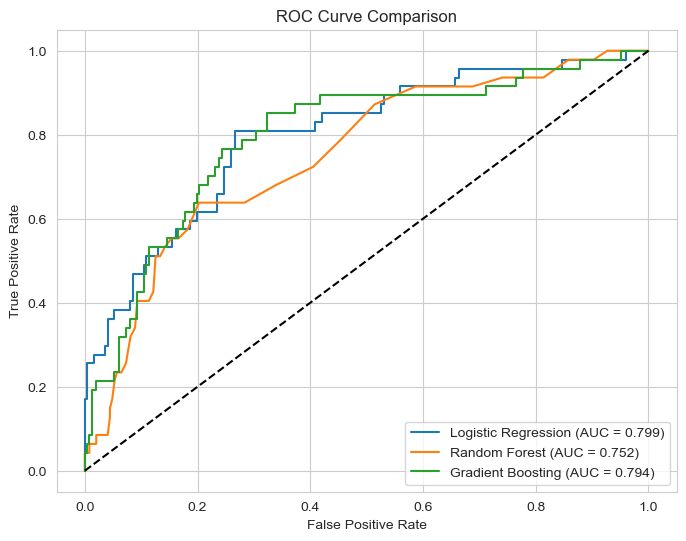

In [26]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

# Task 7 — HR Insights & Business Recommendations

### My analysis suggests that employees are more likely to leave when they work in certain job roles, frequently work overtime, or travel often for work. The **Sales department** requires the most attention because it has the highest employee turnover rate (**20.63%**). Within this department, **Sales Representatives** have the highest turnover (**39.76%**), followed by **Laboratory Technicians** and **Human Resources** employees. The findings also show that salary is not the main reason employees leave. Workload, job responsibilities, travel requirements, and overall work experience have a greater influence on whether employees stay or resign. To improve retention, HR should focus on employees in these high-turnover roles by holding regular career discussions, reducing excessive overtime, supporting a healthier work-life balance, and providing clear opportunities for career growth. These findings should be used to help identify employees who may need additional support, but they should always be considered alongside manager feedback and individual employee circumstances before making any HR decisions.


# Conclusion

### This project successfully analyzed employee attrition using the IBM HR Analytics dataset. After preprocessing, exploratory data analysis, and model comparison, Logistic Regression achieved the best performance with a ROC-AUC of 0.799 and Recall of 0.617. Feature importance analysis revealed that Job Role, OverTime, Business Travel, Job Level, and Total Working Years are the strongest predictors of attrition. These findings can help HR teams identify high-risk employees and design targeted retention strategies.